# phase 5: neural network embeddings (word2vec and fasttext)

this notebook transitions from sparse frequency matrices (tf-idf) to dense continuous vector representations (dense embeddings). the goal is to test the hypothesis that semantic spaces can improve the classification metrics of baseline ml algorithms by capturing synonymy and subword morphology, which are unavailable to the frequency approach.

plan for this stage:
1. data preparation: load the cleaned datasets and strictly reproduce the train/test splits from phase 3 to ensure a valid benchmark.
2. vector spaces integration: load pre-trained word2vec and fasttext models into the data/external/ directory.
3. feature aggregation (mean pooling): write logic to calculate the document centroid based on the vectors of its constituent tokens to form a feature matrix of fixed dimensionality.
4. model training: train the linear svc algorithm (the winner of phase 4) on the generated dense matrices.
5. evaluation & comparison: generate classification reports, calculate macro f1, and directly compare the dense representations with the sparse (tf-idf) ones.

In [3]:
# cell 1: importing libraries and reproducing exact train-test splits from phase 3
import pandas as pd
from sklearn.model_selection import train_test_split

print("loading cleaned datasets...")

# --- model a (sentiment) ---
df_a = pd.read_csv('data/processed/model_a_train_cleaned.csv').dropna(subset=['clean_text'])
x_train_a, x_test_a, y_train_a, y_test_a = train_test_split(
    df_a['clean_text'], 
    df_a['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_a['label']
)

# --- model b (emotions) ---
df_b = pd.read_csv('data/processed/model_b_train_cleaned.csv').dropna(subset=['clean_text'])
emotion_cols = ['sadness', 'anger', 'fear', 'disgust', 'anticipation', 'joy', 'surprise', 'gratitude', 'love']
x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(
    df_b['clean_text'], 
    df_b[emotion_cols], 
    test_size=0.2, 
    random_state=42
)

# --- model c (formality) ---
df_c = pd.read_csv('data/processed/model_c_train_cleaned.csv').dropna(subset=['clean_text'])
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    df_c['clean_text'], 
    df_c['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_c['label']
)

print(f"model a splits - train: {len(x_train_a)}, test: {len(x_test_a)}")
print(f"model b splits - train: {len(x_train_b)}, test: {len(x_test_b)}")
print(f"model c splits - train: {len(x_train_c)}, test: {len(x_test_c)}")
print("data successfully loaded and split.")

loading cleaned datasets...
model a splits - train: 31247, test: 7812
model b splits - train: 15024, test: 3757
model c splits - train: 5480, test: 1370
data successfully loaded and split.


## using pre-trained embeddings

at this stage, we load the external weights of the word2vec and fasttext models into the `data/external/` directory. the decision to use external vectors instead of training on our own data is driven by the following factors:

1. **insufficient volume of local data:** forming a high-quality semantic space (where vectors of synonyms are truly close) requires billions of tokens. our dataset (~40,000 texts) is too small for the algorithm to independently derive complex lexical relationships.
2. **generalization ability:** models trained on massive corpora (google news, wikipedia) already encapsulate linguistic "knowledge". this allows the classifier to correctly process words in the test set that might not have appeared during training but have embeddings close to known concepts.
3. **solving the oov (out-of-vocabulary) problem:** using pre-trained fasttext is critical for handling slang and typos in the goemotions and pavlick datasets. through subword n-grams, the model will construct a vector even for an unknown token, relying on its morphological structure.

In [1]:
# cell 2: downloading and caching pre-trained word2vec and fasttext models
import os
import gensim.downloader as api
from gensim.models import KeyedVectors

os.makedirs('data/external', exist_ok=True)

w2v_path = 'data/external/word2vec-google-news-300.wordvectors'
ft_path = 'data/external/fasttext-wiki-news-subwords-300.wordvectors'

print("initializing word2vec (google news 300)...")
if not os.path.exists(w2v_path):
    print("downloading word2vec weights (this may take a while)...")
    w2v_model = api.load('word2vec-google-news-300')
    # saving the keyedvectors to our project structure
    w2v_model.save(w2v_path)
    print(f"word2vec saved to {w2v_path}")
else:
    w2v_model = KeyedVectors.load(w2v_path)
    print("word2vec loaded from local cache.")

print("\ninitializing fasttext (wiki news subwords 300)...")
if not os.path.exists(ft_path):
    print("downloading fasttext weights (this may take a while)...")
    ft_model = api.load('fasttext-wiki-news-subwords-300')
    ft_model.save(ft_path)
    print(f"fasttext saved to {ft_path}")
else:
    ft_model = KeyedVectors.load(ft_path)
    print("fasttext loaded from local cache.")

print(f"\nword2vec vector size: {w2v_model.vector_size}")
print(f"fasttext vector size: {ft_model.vector_size}")

initializing word2vec (google news 300)...
word2vec loaded from local cache.

initializing fasttext (wiki news subwords 300)...
fasttext loaded from local cache.

word2vec vector size: 300
fasttext vector size: 300


In [4]:
# cell 3: feature aggregation (mean pooling transformer)
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MeanEmbeddingVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, word_model):
        self.word_model = word_model
        self.vector_size = word_model.vector_size

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        # x is expected to be a list or pandas series of strings
        doc_vectors = []
        for text in x:
            # texts are already cleaned, so simple split is sufficient
            words = str(text).split()
            word_vectors = []
            
            for word in words:
                if word in self.word_model:
                    word_vectors.append(self.word_model[word])
            
            if len(word_vectors) > 0:
                # geometric centroid of all known words in the text
                doc_vectors.append(np.mean(word_vectors, axis=0))
            else:
                # zero vector if all words are out-of-vocabulary (oov)
                doc_vectors.append(np.zeros(self.vector_size))
                
        return np.array(doc_vectors)

print("initializing mean pooling transformers...")
w2v_vectorizer = MeanEmbeddingVectorizer(w2v_model)
ft_vectorizer = MeanEmbeddingVectorizer(ft_model)

# transforming model a (sentiment)
print("vectorizing model a datasets...")
x_train_a_w2v = w2v_vectorizer.transform(x_train_a)
x_test_a_w2v = w2v_vectorizer.transform(x_test_a)

x_train_a_ft = ft_vectorizer.transform(x_train_a)
x_test_a_ft = ft_vectorizer.transform(x_test_a)

# transforming model c (formality)
print("vectorizing model c datasets...")
x_train_c_w2v = w2v_vectorizer.transform(x_train_c)
x_test_c_w2v = w2v_vectorizer.transform(x_test_c)

x_train_c_ft = ft_vectorizer.transform(x_train_c)
x_test_c_ft = ft_vectorizer.transform(x_test_c)

# transforming model b (emotions)
print("vectorizing model b datasets...")
x_train_b_w2v = w2v_vectorizer.transform(x_train_b)
x_test_b_w2v = w2v_vectorizer.transform(x_test_b)

x_train_b_ft = ft_vectorizer.transform(x_train_b)
x_test_b_ft = ft_vectorizer.transform(x_test_b)

print(f"model a matrices shape (w2v): {x_train_a_w2v.shape}")
print(f"model a matrices shape (ft): {x_train_a_ft.shape}")
print("==================================")
print(f"model b matrices shape (w2v): {x_train_b_w2v.shape}")
print(f"model b matrices shape (ft): {x_train_b_ft.shape}")
print("==================================")
print(f"model c matrices shape (w2v): {x_train_c_w2v.shape}")
print(f"model c matrices shape (ft): {x_train_c_ft.shape}")
print("all text data successfully projected into 300-dimensional semantic space.")

initializing mean pooling transformers...
vectorizing model a datasets...
vectorizing model c datasets...
vectorizing model b datasets...
model a matrices shape (w2v): (31247, 300)
model a matrices shape (ft): (31247, 300)
model b matrices shape (w2v): (15024, 300)
model b matrices shape (ft): (15024, 300)
model c matrices shape (w2v): (5480, 300)
model c matrices shape (ft): (5480, 300)
all text data successfully projected into 300-dimensional semantic space.


In [5]:
# cell 4: training linear svc on dense embeddings (word2vec and fasttext)
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
import time

print("training linear svc models on dense word2vec matrices...")
# we use dual=False because n_samples > n_features in our dense matrices
# model a
start_time = time.time()
svc_a_w2v = LinearSVC(random_state=42, dual=False, max_iter=2000)
svc_a_w2v.fit(x_train_a_w2v, y_train_a)
print(f"model a (w2v) trained in {time.time() - start_time:.4f} seconds")
print(f"iterations to converge: {svc_a_w2v.n_iter_}\n")

# model c
start_time = time.time()
svc_c_w2v = LinearSVC(random_state=42, dual=False, max_iter=2000)
svc_c_w2v.fit(x_train_c_w2v, y_train_c)
print(f"model c (w2v) trained in {time.time() - start_time:.4f} seconds")
print(f"iterations to converge: {svc_c_w2v.n_iter_}\n")

# model b (multi-label requires one-vs-rest)
start_time = time.time()
base_svc_b = LinearSVC(random_state=42, dual=False, max_iter=2000)
svc_b_w2v_ovr = OneVsRestClassifier(base_svc_b)
svc_b_w2v_ovr.fit(x_train_b_w2v, y_train_b)
print(f"model b (w2v) trained in {time.time() - start_time:.4f} seconds")
print(f"iterations to converge for each emotion: {[est.n_iter_ for est in svc_b_w2v_ovr.estimators_]}\n")


print("training linear svc models on dense fasttext matrices...")

# model a
start_time = time.time()
svc_a_ft = LinearSVC(random_state=42, dual=False, max_iter=2000)
svc_a_ft.fit(x_train_a_ft, y_train_a)
print(f"model a (ft) trained in {time.time() - start_time:.4f} seconds")
print(f"iterations to converge: {svc_a_ft.n_iter_}\n")

# model c
start_time = time.time()
svc_c_ft = LinearSVC(random_state=42, dual=False, max_iter=2000)
svc_c_ft.fit(x_train_c_ft, y_train_c)
print(f"model c (ft) trained in {time.time() - start_time:.4f} seconds")
print(f"iterations to converge: {svc_c_ft.n_iter_}\n")

# model b
start_time = time.time()
base_svc_b_ft = LinearSVC(random_state=42, dual=False, max_iter=2000)
svc_b_ft_ovr = OneVsRestClassifier(base_svc_b_ft)
svc_b_ft_ovr.fit(x_train_b_ft, y_train_b)
print(f"model b (ft) trained in {time.time() - start_time:.4f} seconds")
print(f"iterations to converge for each emotion: {[est.n_iter_ for est in svc_b_ft_ovr.estimators_]}\n")

print("all models successfully trained on dense embeddings.")

training linear svc models on dense word2vec matrices...
model a (w2v) trained in 4.3384 seconds
iterations to converge: 8

model c (w2v) trained in 0.2015 seconds
iterations to converge: 6

model b (w2v) trained in 3.3826 seconds
iterations to converge for each emotion: [10, 8, 11, 10, 10, 8, 10, 8, 10]

training linear svc models on dense fasttext matrices...
model a (ft) trained in 4.7405 seconds
iterations to converge: 12

model c (ft) trained in 0.2246 seconds
iterations to converge: 6

model b (ft) trained in 5.2810 seconds
iterations to converge for each emotion: [11, 10, 11, 11, 12, 10, 11, 11, 11]

all models successfully trained on dense embeddings.


### understanding `n_samples > n_features` and the `dual=False` parameter

in support vector machines (svm), the optimization problem can be solved in two ways: the primal formulation or the dual formulation. the `dual` parameter in scikit-learn's `linearsvc` controls which mathematical approach is used under the hood.

1. **the dimensionality context:** * `n_samples` represents the number of texts in our training set (e.g., ~$31,000$ for model a).
   * `n_features` represents the dimensionality of our vector space. in phase 4 (tf-idf), `n_features` was $10,000$. in phase 5 (dense embeddings), `n_features` is exactly $300$.
   * therefore, we have transitioned from a wide, sparse matrix to a narrow, dense matrix where `n_samples` $\gg$ `n_features`.

2. **why `dual=False`:**
   according to the underlying `liblinear` library documentation, when the number of samples is significantly greater than the number of features, solving the primal optimization problem (`dual=False`) is mathematically faster and consumes less memory. the dual formulation scales with the number of samples, making it computationally expensive for large datasets with low-dimensional dense vectors.

In [6]:
# cell 5: evaluating linear svc on dense embeddings
from sklearn.metrics import classification_report

print("--- model a (sentiment) evaluation ---")
y_pred_a_w2v = svc_a_w2v.predict(x_test_a_w2v)
y_pred_a_ft = svc_a_ft.predict(x_test_a_ft)

print("[ word2vec ]")
print(classification_report(y_test_a, y_pred_a_w2v, target_names=['negative', 'positive', 'neutral']))
print("[ fasttext ]")
print(classification_report(y_test_a, y_pred_a_ft, target_names=['negative', 'positive', 'neutral']))

print("\n--- model b (emotions) evaluation ---")
y_pred_b_w2v = svc_b_w2v_ovr.predict(x_test_b_w2v)
y_pred_b_ft = svc_b_ft_ovr.predict(x_test_b_ft)

print("[ word2vec ]")
print(classification_report(y_test_b, y_pred_b_w2v, target_names=y_train_b.columns, zero_division=0))
print("[ fasttext ]")
print(classification_report(y_test_b, y_pred_b_ft, target_names=y_train_b.columns, zero_division=0))

print("\n--- model c (formality) evaluation ---")
y_pred_c_w2v = svc_c_w2v.predict(x_test_c_w2v)
y_pred_c_ft = svc_c_ft.predict(x_test_c_ft)

print("[ word2vec ]")
print(classification_report(y_test_c, y_pred_c_w2v, target_names=['informal', 'formal']))
print("[ fasttext ]")
print(classification_report(y_test_c, y_pred_c_ft, target_names=['informal', 'formal']))

--- model a (sentiment) evaluation ---
[ word2vec ]
              precision    recall  f1-score   support

    negative       0.80      0.74      0.77      2500
    positive       0.78      0.79      0.79      2500
     neutral       0.84      0.89      0.86      2812

    accuracy                           0.81      7812
   macro avg       0.81      0.81      0.81      7812
weighted avg       0.81      0.81      0.81      7812

[ fasttext ]
              precision    recall  f1-score   support

    negative       0.80      0.71      0.75      2500
    positive       0.76      0.80      0.78      2500
     neutral       0.85      0.89      0.87      2812

    accuracy                           0.81      7812
   macro avg       0.80      0.80      0.80      7812
weighted avg       0.80      0.81      0.80      7812


--- model b (emotions) evaluation ---
[ word2vec ]
              precision    recall  f1-score   support

     sadness       0.75      0.28      0.41       260
       anger

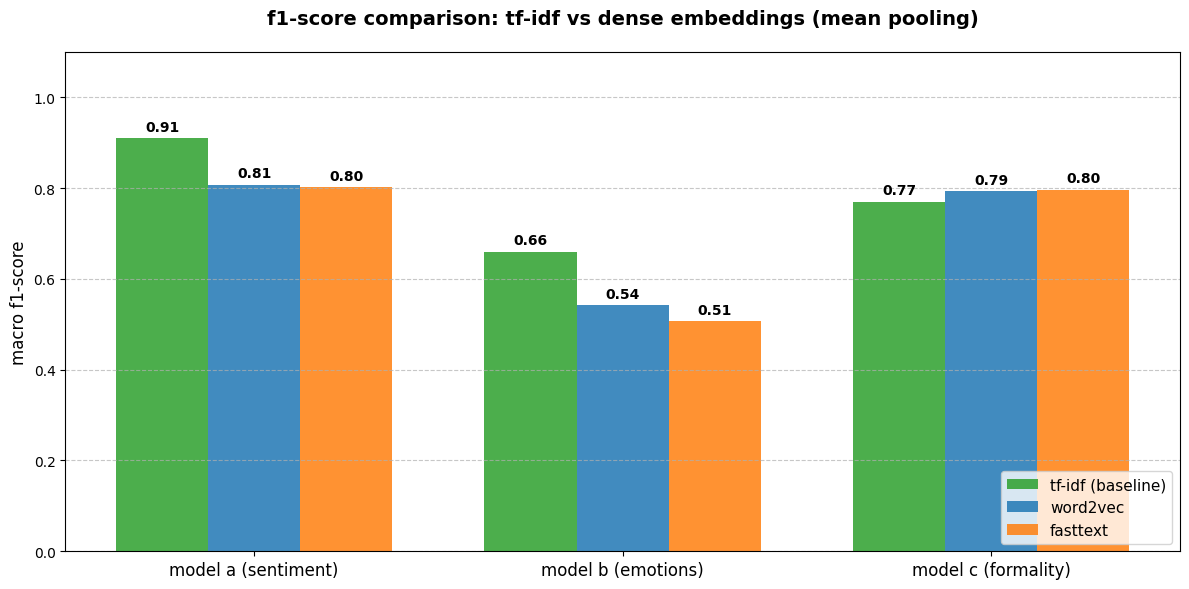

In [7]:
# cell 6: visual comparison of tf-idf (baseline) vs word2vec vs fasttext
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def get_macro_metrics(y_true, y_pred):
    """calculates macro precision, recall, and f1."""
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return p, r, f

# 1. extract current metrics for word2vec
metrics_a_w2v = get_macro_metrics(y_test_a, y_pred_a_w2v)
metrics_b_w2v = get_macro_metrics(y_test_b, y_pred_b_w2v)
metrics_c_w2v = get_macro_metrics(y_test_c, y_pred_c_w2v)

# 2. extract current metrics for fasttext
metrics_a_ft = get_macro_metrics(y_test_a, y_pred_a_ft)
metrics_b_ft = get_macro_metrics(y_test_b, y_pred_b_ft)
metrics_c_ft = get_macro_metrics(y_test_c, y_pred_c_ft)

# 3. hardcoded baseline metrics from phase 4 (tf-idf + linear svc)
metrics_a_tfidf = (0.91, 0.91, 0.91)
metrics_b_tfidf = (0.79, 0.58, 0.66)
metrics_c_tfidf = (0.77, 0.77, 0.77)

algorithms = ['tf-idf (baseline)', 'word2vec', 'fasttext']
tasks = ['model a (sentiment)', 'model b (emotions)', 'model c (formality)']

# unpack data for plotting (f1-score only for clean comparison)
f1_data = [
    [metrics_a_tfidf[2], metrics_b_tfidf[2], metrics_c_tfidf[2]], # tf-idf
    [metrics_a_w2v[2], metrics_b_w2v[2], metrics_c_w2v[2]],       # w2v
    [metrics_a_ft[2], metrics_b_ft[2], metrics_c_ft[2]]           # ft
]

# plotting setup
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(tasks))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e'] # green, blue, orange

for i, (alg, color) in enumerate(zip(algorithms, colors)):
    bars = ax.bar(x + i*bar_width, f1_data[i], bar_width, label=alg, color=color, alpha=0.85)
    
    # add text labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('f1-score comparison: tf-idf vs dense embeddings (mean pooling)', pad=20, fontsize=14, fontweight='bold')
ax.set_ylabel('macro f1-score', fontsize=12)
ax.set_xticks(x + bar_width)
ax.set_xticklabels(tasks, fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

### phase 5 conclusion: why dense embeddings underperformed

the evaluation shows a significant drop in macro f1-scores across models a and b when comparing dense embeddings (word2vec/fasttext) to the tf-idf baseline. 

**mathematical reasons for the drop:**
1. **loss of linear separability:** tf-idf represented texts in a 10,000-dimensional sparse space, making it easy for linear svc to find separating hyperplanes (cover's theorem). collapsing this space to 300 dimensions forces classes to overlap geometrically, breaking linear models.
2. **mean pooling degradation:** taking the arithmetic mean of all word vectors in a document heavily dilutes strong semantic signals. the vector of a highly emotional word (e.g., "garbage") gets averaged out by the vectors of surrounding neutral words, dragging the document's centroid toward the origin.
3. **domain mismatch:** google news and wikipedia weights are trained on formal text. their semantic geometry does not perfectly map to the informal, emotional slang found in imdb and reddit (goemotions) datasets.

**next step:** dense embeddings hold complex semantic relationships, but applying simple linear logic (mean pooling + svc) destroys this potential. to extract value from spatial embeddings, we must transition to deep neural networks (lstm, cnn) that can process sequence topology without averaging.